# Modelo de Clasificación — Predicción de Puntaje Global Saber 11

**Proyecto 2 — Analítica Computacional para la Toma de Decisiones**  
**Universidad de los Andes**  
**Autor:** Luis Enrique Restrepo
**Rol:** Ciencia de Datos  

**Pregunta de negocio:** ¿Es posible predecir si un estudiante proviene de una zona rural o urbana a partir únicamente de sus resultados y perfil familiar, y qué tan marcada es esa brecha en Bolívar?

## 1. Carga de datos limpios

Cargamos el dataframe ya procesado por el script de limpieza `Proyecto2.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('DatosSaber11_Bolivar_limpio_todas_columnas.csv')
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()
df.dtypes

Filas: 122,866
Columnas: 52


estu_consecutivo                  object
periodo                            int64
estu_fechanacimiento              object
edad                               int64
estu_genero                       object
cole_area_ubicacion               object
cole_mcpio_ubicacion              object
cole_calendario                   object
cole_bilingue                     object
cole_naturaleza                   object
cole_genero                       object
cole_caracter                     object
fami_estratovivienda              object
fami_tienecomputador              object
fami_tieneinternet                object
fami_educacionmadre               object
fami_educacionpadre               object
punt_ingles                      float64
punt_matematicas                 float64
punt_lectura_critica               int64
punt_c_naturales                   int64
punt_sociales_ciudadanas           int64
punt_global                      float64
estu_tipodocumento                object
cole_cod_dane_es

In [3]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numéricas ({len(num_cols)}):    {num_cols}")
print(f"\nCategóricas ({len(cat_cols)}): {cat_cols}")

Numéricas (17):    ['periodo', 'edad', 'punt_ingles', 'punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_global', 'cole_cod_dane_establecimiento', 'cole_cod_dane_sede', 'cole_cod_depto_ubicacion', 'cole_cod_mcpio_ubicacion', 'cole_codigo_icfes', 'estu_cod_depto_presentacion', 'estu_cod_mcpio_presentacion', 'estu_cod_reside_depto', 'estu_cod_reside_mcpio']

Categóricas (35): ['estu_consecutivo', 'estu_fechanacimiento', 'estu_genero', 'cole_area_ubicacion', 'cole_mcpio_ubicacion', 'cole_calendario', 'cole_bilingue', 'cole_naturaleza', 'cole_genero', 'cole_caracter', 'fami_estratovivienda', 'fami_tienecomputador', 'fami_tieneinternet', 'fami_educacionmadre', 'fami_educacionpadre', 'estu_tipodocumento', 'cole_depto_ubicacion', 'cole_jornada', 'cole_nombre_establecimiento', 'cole_nombre_sede', 'cole_sede_principal', 'estu_depto_presentacion', 'estu_depto_reside', 'estu_estadoinvestigacion', 'estu_estudiante', 'estu_mcpio_presentacion', 'estu_mc

Variable Ojetivo

In [4]:
TARGET = 'cole_area_ubicacion'

print("Valores únicos:", df[TARGET].unique())
print("\nConteo:")
print(df[TARGET].value_counts())
print("\nProporción %:")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))

Valores únicos: ['URBANO' 'RURAL']

Conteo:
cole_area_ubicacion
URBANO    100877
RURAL      21989
Name: count, dtype: int64

Proporción %:
cole_area_ubicacion
URBANO    82.1
RURAL     17.9
Name: proportion, dtype: float64


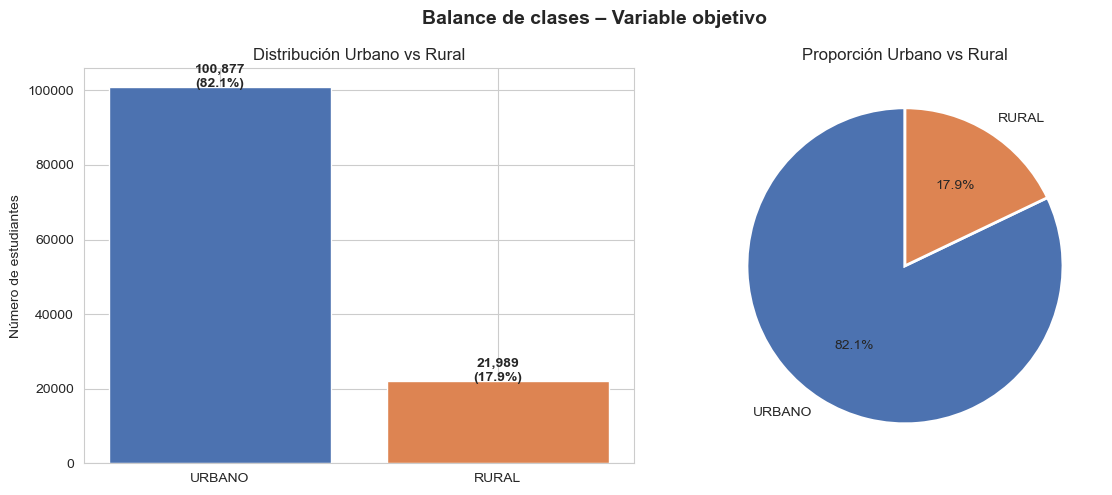


Ratio desbalance: 4.59x


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df[TARGET].value_counts()

axes[0].bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'], edgecolor='white')
for i, (val, count) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, count + 50, f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Distribución Urbano vs Rural')
axes[0].set_ylabel('Número de estudiantes')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción Urbano vs Rural')

plt.suptitle('Balance de clases – Variable objetivo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRatio desbalance: {counts.iloc[0]/counts.iloc[1]:.2f}x")

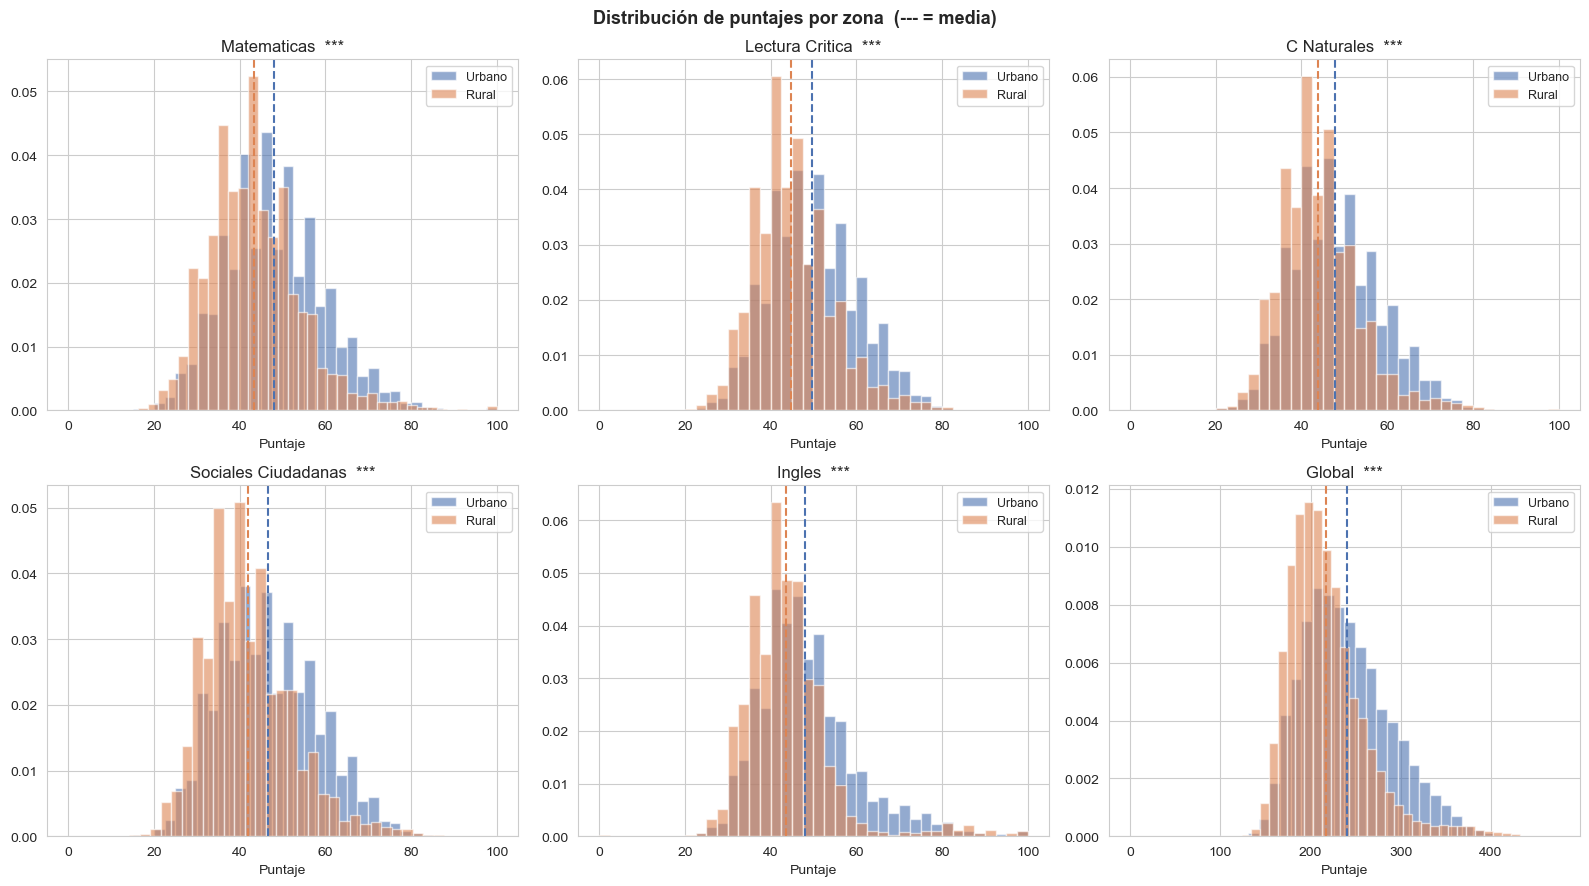

In [6]:
puntajes = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
            'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(puntajes):
    urbano = df[df[TARGET] == 'URBANO'][col].dropna()
    rural  = df[df[TARGET] == 'RURAL'][col].dropna()

    axes[i].hist(urbano, bins=40, alpha=0.6, label='Urbano', color='#4C72B0', density=True)
    axes[i].hist(rural,  bins=40, alpha=0.6, label='Rural',  color='#DD8452', density=True)
    axes[i].axvline(urbano.mean(), color='#4C72B0', linestyle='--', linewidth=1.5)
    axes[i].axvline(rural.mean(),  color='#DD8452', linestyle='--', linewidth=1.5)

    t_stat, p_val = stats.ttest_ind(urbano, rural)
    sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))

    nombre = col.replace('punt_','').replace('_',' ').title()
    axes[i].set_title(f"{nombre}  {sig}")
    axes[i].set_xlabel('Puntaje')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de puntajes por zona  (--- = media)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

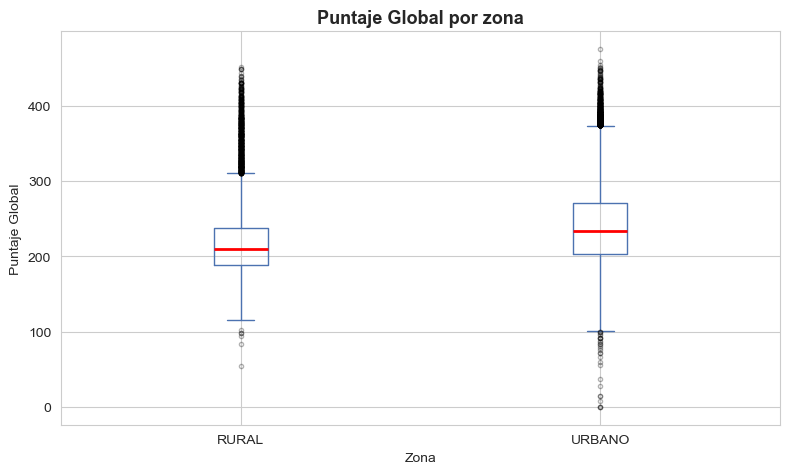

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
df.boxplot(column='punt_global', by=TARGET, ax=ax,
           boxprops=dict(color='#4C72B0'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='#4C72B0'),
           capprops=dict(color='#4C72B0'),
           flierprops=dict(marker='o', alpha=0.3, markersize=3))
ax.set_title('Puntaje Global por zona', fontsize=13, fontweight='bold')
ax.set_xlabel('Zona')
ax.set_ylabel('Puntaje Global')
plt.suptitle('')
plt.tight_layout()
plt.show()

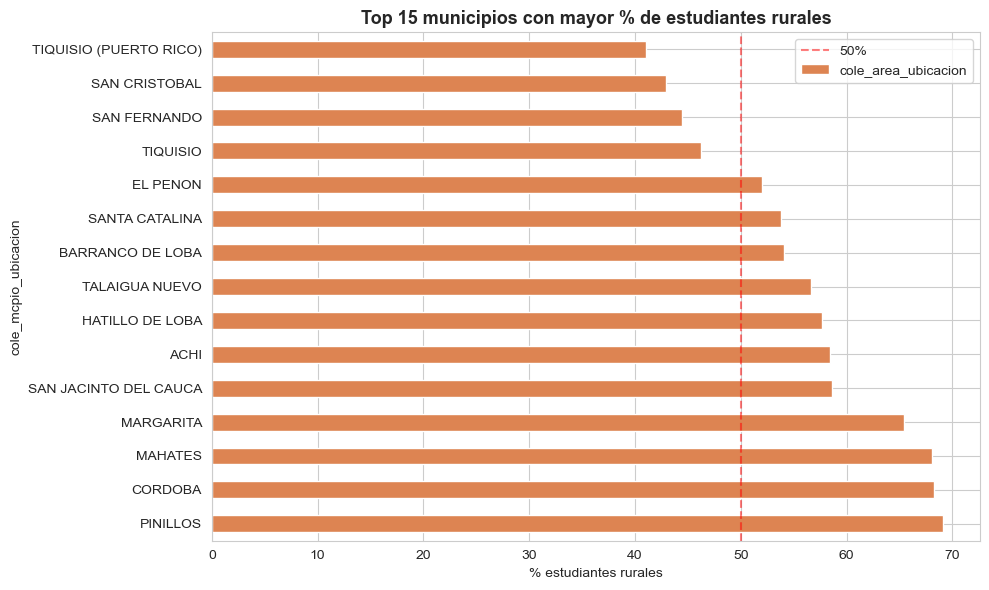

In [8]:
municipios = (df.groupby('cole_mcpio_ubicacion')[TARGET]
                .apply(lambda x: (x == 'RURAL').mean() * 100)
                .sort_values(ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
municipios.plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_title('Top 15 municipios con mayor % de estudiantes rurales', fontsize=13, fontweight='bold')
ax.set_xlabel('% estudiantes rurales')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Análisis de correlaciones (¿las X tienen señal sobre la Y?)


#### Corrrelación puntajes

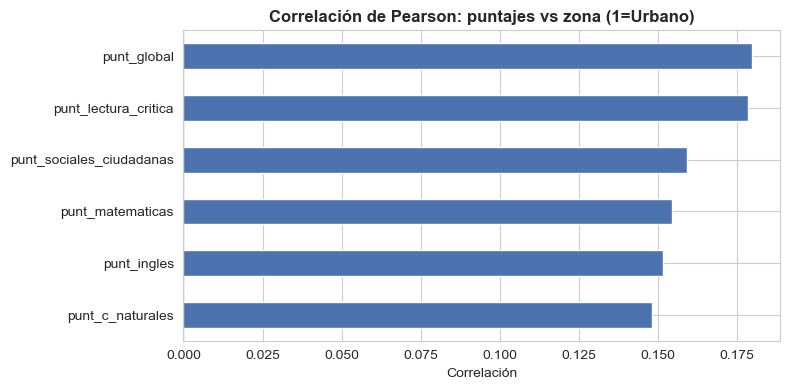

punt_c_naturales            0.148354
punt_ingles                 0.151585
punt_matematicas            0.154640
punt_sociales_ciudadanas    0.159307
punt_lectura_critica        0.178518
punt_global                 0.179709
Name: zona_bin, dtype: float64


In [11]:
df_corr = df.copy()
df_corr['zona_bin'] = (df_corr[TARGET] == 'URBANO').astype(int)

puntajes = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
            'punt_sociales_ciudadanas', 'punt_ingles', 'punt_global']

corr_puntajes = df_corr[puntajes + ['zona_bin']].corr()['zona_bin'].drop('zona_bin').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DD8452' if v < 0 else '#4C72B0' for v in corr_puntajes.values]
corr_puntajes.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson: puntajes vs zona (1=Urbano)', fontweight='bold')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

print(corr_puntajes)

#### Correlación categoricas

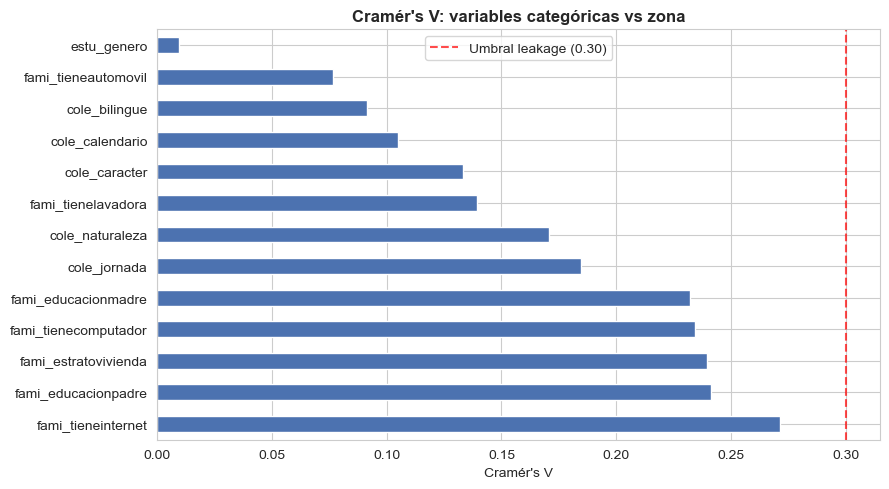

fami_tieneinternet      0.271551
fami_educacionpadre     0.241247
fami_estratovivienda    0.239386
fami_tienecomputador    0.234516
fami_educacionmadre     0.231982
cole_jornada            0.184747
cole_naturaleza         0.170659
fami_tienelavadora      0.139336
cole_caracter           0.133348
cole_calendario         0.105059
cole_bilingue           0.091543
fami_tieneautomovil     0.076738
estu_genero             0.009485
dtype: float64


In [16]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    return np.sqrt(chi2 / (n * (min(cm.shape) - 1)))

cat_vars_test = ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre',
                 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador',
                 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza',
                 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']

cat_vars_test = [c for c in cat_vars_test if c in df.columns]

cramers = {}
for col in cat_vars_test:
    tmp = df[[col, TARGET]].dropna()
    cramers[col] = cramers_v(tmp[col], tmp[TARGET])

cramers_s = pd.Series(cramers).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_c = ['#e74c3c' if v > 0.3 else '#4C72B0' for v in cramers_s.values]
cramers_s.plot(kind='barh', ax=ax, color=colors_c)
ax.axvline(0.3, color='red', linestyle='--', alpha=0.7, label='Umbral leakage (0.30)')
ax.set_title("Cramér's V: variables categóricas vs zona", fontweight='bold')
ax.set_xlabel("Cramér's V")
ax.legend()
plt.tight_layout()
plt.show()

print(cramers_s)

In [17]:
cat_int_feats = []   # en este dataset estrato y género son string

cat_str_feats = ['estu_genero', 'fami_estratovivienda',
                 'fami_educacionpadre', 'fami_educacionmadre',
                 'fami_tieneinternet', 'fami_tienecomputador',
                 'fami_tieneautomovil', 'fami_tienelavadora',
                 'cole_naturaleza', 'cole_jornada', 'cole_bilingue',
                 'cole_caracter', 'cole_calendario']

# No se tiene en cuenta 'punt_global' para evitar data leakage, aunque es la variable con mayor correlación
num_feats = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
             'punt_sociales_ciudadanas', 'punt_ingles',
             'edad']

# Verificar existencia
cat_str_feats = [c for c in cat_str_feats if c in df.columns]
num_feats     = [c for c in num_feats     if c in df.columns]

print("Categóricas string:", cat_str_feats)
print("Numéricas:         ", num_feats)

all_feats = cat_int_feats + cat_str_feats + num_feats
df_model  = df[all_feats + [TARGET]].dropna().copy()
df_model[TARGET] = (df_model[TARGET] == 'URBANO').astype(int)

print(f"\nFilas para modelar: {len(df_model):,}")
print(f"Balance:\n{df_model[TARGET].value_counts()}")
df_model.head()

Categóricas string: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']
Numéricas:          ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'edad']

Filas para modelar: 122,866
Balance:
cole_area_ubicacion
1    100877
0     21989
Name: count, dtype: int64


,estu_genero,fami_estratovivienda,fami_educacionpadre,fami_educacionmadre,fami_tieneinternet,fami_tienecomputador,fami_tieneautomovil,fami_tienelavadora,cole_naturaleza,cole_jornada,cole_bilingue,cole_caracter,cole_calendario,punt_matematicas,punt_lectura_critica,punt_c_naturales,punt_sociales_ciudadanas,punt_ingles,edad,cole_area_ubicacion
0,M,ESTRATO 1,PRIMARIA COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,NO,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,47.0,49,51,32,51.0,17,1
1,M,ESTRATO 3,EDUCACION PROFESIONAL COMPLETA,EDUCACION PROFESIONAL COMPLETA,SI,SI,No,Si,OFICIAL,TARDE,N,TECNICO/ACADEMICO,A,62.0,68,67,71,100.0,17,1
2,F,ESTRATO 3,NINGUNO,SECUNDARIA (BACHILLERATO) COMPLETA,NO,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,26.0,36,39,25,39.0,16,1
3,M,SIN ESTRATO,SECUNDARIA (BACHILLERATO) COMPLETA,SECUNDARIA (BACHILLERATO) COMPLETA,SI,NO,No,Si,OFICIAL,MAÑANA,N,ACADEMICO,A,25.0,35,36,32,42.0,17,0
4,F,ESTRATO 1,TECNICA O TECNOLOGICA INCOMPLETA,TECNICA O TECNOLOGICA INCOMPLETA,SI,SI,No,Si,OFICIAL,NOCHE,N,ACADEMICO,A,52.0,52,51,48,45.0,18,1


In [18]:
cat_str_feats = ['estu_genero', 'fami_estratovivienda',
                 'fami_educacionpadre', 'fami_educacionmadre',
                 'fami_tieneinternet', 'fami_tienecomputador',
                 'fami_tieneautomovil', 'fami_tienelavadora',
                 'cole_naturaleza', 'cole_jornada', 'cole_bilingue',
                 'cole_caracter', 'cole_calendario']

# No se tiene en cuenta 'punt_global' para evitar data leakage, aunque es la variable con mayor correlación
num_feats = ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales',
             'punt_sociales_ciudadanas', 'punt_ingles', 'edad']

cat_str_feats = [c for c in cat_str_feats if c in df.columns]
num_feats     = [c for c in num_feats     if c in df.columns]

print("Categóricas string:", cat_str_feats)
print("Numéricas:         ", num_feats)

all_feats = cat_str_feats + num_feats
df_model  = df[all_feats + [TARGET]].dropna().copy()
df_model[TARGET] = (df_model[TARGET] == 'URBANO').astype(int)

print(f"\nFilas para modelar: {len(df_model):,}")
print(f"\nBalance:")
print(df_model[TARGET].value_counts())
print(df_model[TARGET].value_counts(normalize=True).round(3) * 100)

Categóricas string: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario']
Numéricas:          ['punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'edad']

Filas para modelar: 122,866

Balance:
cole_area_ubicacion
1    100877
0     21989
Name: count, dtype: int64
cole_area_ubicacion
1    82.1
0    17.9
Name: proportion, dtype: float64


In [19]:
import tensorflow as tf
import keras
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.14.1


Seprar entre train y test

In [20]:
train = df_model.sample(frac=0.8, random_state=42)
test  = df_model.drop(train.index)

val   = train.sample(frac=0.2, random_state=42)
train = train.drop(val.index)

print(f"Train: {train.shape[0]:,} filas")
print(f"Val:   {val.shape[0]:,} filas")
print(f"Test:  {test.shape[0]:,} filas")

Train: 78,634 filas
Val:   19,659 filas
Test:  24,573 filas


Convertir a tf.Dataset

In [21]:
def dataframe_to_dataset(dataframe, shuffle=True):
    dataframe = dataframe.copy()
    labels = dataframe.pop(TARGET)
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train)
val_ds   = dataframe_to_dataset(val)
test_ds  = dataframe_to_dataset(test)

batch_size = 32
train_ds = train_ds.batch(batch_size)
val_ds   = val_ds.batch(batch_size)
test_ds  = test_ds.batch(batch_size)

print("Datasets creados")
for x, y in train_ds.take(1):
    print("Features:", list(x.keys()))
    print("Etiquetas ejemplo:", y.numpy()[:5])

Datasets creados
Features: ['estu_genero', 'fami_estratovivienda', 'fami_educacionpadre', 'fami_educacionmadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'fami_tienelavadora', 'cole_naturaleza', 'cole_jornada', 'cole_bilingue', 'cole_caracter', 'cole_calendario', 'punt_matematicas', 'punt_lectura_critica', 'punt_c_naturales', 'punt_sociales_ciudadanas', 'punt_ingles', 'edad']
Etiquetas ejemplo: [1 0 1 1 1]


Funciones de codificación para ayuda a normalizar variables como el puntaje y la edad, tmabien las que son varuables como SI/NO a numeros para la redes

In [22]:
def encode_numerical_feature(feature, name, dataset):
    normalizer = keras.layers.Normalization()
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    normalizer.adapt(feature_ds)
    return normalizer(feature)

def encode_categorical_feature(feature, name, dataset, is_string):
    lookup = keras.layers.StringLookup(output_mode="binary")
    feature_ds = dataset.map(lambda x, y: x[name])
    feature_ds = feature_ds.map(lambda x: tf.expand_dims(x, -1))
    lookup.adapt(feature_ds)
    return lookup(feature)


In [23]:
inputs = []

for feat in cat_str_feats:
    inputs.append(keras.Input(shape=(1,), name=feat, dtype="string"))

for feat in num_feats:
    inputs.append(keras.Input(shape=(1,), name=feat, dtype="float32"))

print(f"Total inputs: {len(inputs)}")

Total inputs: 19


In [24]:
feats_encoded = []

# Categóricas string
for i, feat in enumerate(cat_str_feats):
    feats_encoded.append(
        encode_categorical_feature(inputs[i], feat, train_ds, is_string=True)
    )

# Numéricas
offset = len(cat_str_feats)
for i, feat in enumerate(num_feats):
    feats_encoded.append(
        encode_numerical_feature(inputs[offset + i], feat, train_ds)
    )

print(f"Total features codificadas: {len(feats_encoded)}")

Total features codificadas: 19


In [25]:
# Concatenar todas las features en una sola capa
all_feats_concat = keras.layers.concatenate(feats_encoded)

# Capas ocultas
x = keras.layers.Dense(64, activation='relu')(all_feats_concat)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(32, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(16, activation='relu')(x)

# Capa de salida
output = keras.layers.Dense(1, activation='sigmoid')(x)

# Crear modelo
model = keras.Model(inputs=inputs, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.Precision(name='precision')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ estu_genero         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_estratovivien… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_educacionpadre │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_educacionmadre │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tieneinternet  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tienecomputad… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tieneautomovil │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fami_tienelavadora  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_naturaleza     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_jornada        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_bilingue       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_caracter       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cole_calendario     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_matematicas    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_lectura_criti… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_c_naturales    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ punt_sociales_ciud… │ (None, 1)         │          0 │ -               

 Total params: 7,571 (29.60 KB)

 Trainable params: 7,553 (29.50 KB)

 Non-trainable params: 18 (96.00 B)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[early_stopping],
    verbose=1
)
# Verificar métricas
resultados = model.evaluate(test_ds, verbose=0)
print(f"accuracy: {resultados[1]:.4f}")
print(f"auc:      {resultados[2]:.4f}")

Epoch 1/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8244 - auc: 0.8083 - loss: 0.3747 - precision: 0.8398 - recall: 0.9715 - val_accuracy: 0.8364 - val_auc: 0.8432 - val_loss: 0.3495 - val_precision: 0.8539 - val_recall: 0.9656
Epoch 2/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8331 - auc: 0.8373 - loss: 0.3525 - precision: 0.8544 - recall: 0.9603 - val_accuracy: 0.8355 - val_auc: 0.8513 - val_loss: 0.3423 - val_precision: 0.8494 - val_recall: 0.9716
Epoch 3/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8351 - auc: 0.8445 - loss: 0.3451 - precision: 0.8563 - recall: 0.9602 - val_accuracy: 0.8347 - val_auc: 0.8552 - val_loss: 0.3392 - val_precision: 0.8408 - val_recall: 0.9849
Epoch 4/50
2458/2458 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8363 - auc: 0.8479 - loss: 0.3411 - precision: 0.8568 - recall: 0.9613 - val_accuracy: 0.8400 - val_auc: 0.8571 - val_loss: 0.3344 - val_precision: 0.8604 - val_recall: 0.9607
Epoch 5/50
2458/2458 ━━━

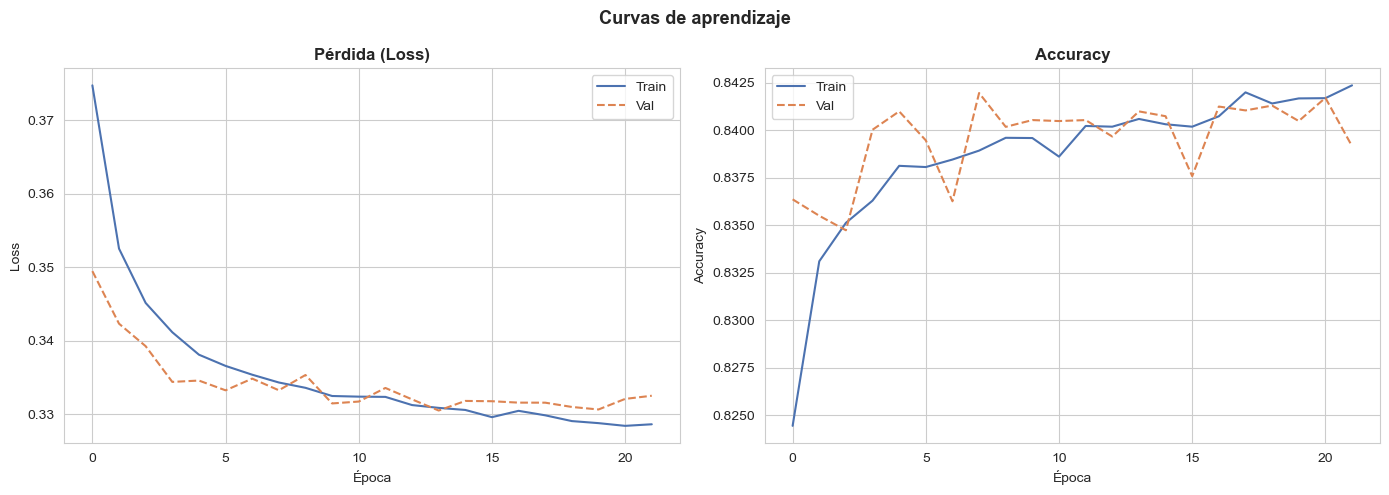

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train', color='#4C72B0')
axes[0].plot(history.history['val_loss'], label='Val',   color='#DD8452', linestyle='--')
axes[0].set_title('Pérdida (Loss)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train', color='#4C72B0')
axes[1].plot(history.history['val_accuracy'], label='Val',   color='#DD8452', linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Curvas de aprendizaje', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
resultados = model.evaluate(test_ds, verbose=0)
metricas   = ['loss', 'accuracy', 'auc', 'recall', 'precision']

print("=== RESULTADOS EN TEST ===")
for m, v in zip(metricas, resultados):
    print(f"  {m:12s}: {v:.4f}")

=== RESULTADOS EN TEST ===
  loss        : 0.3328
  accuracy    : 0.8431
  auc         : 0.8538
  recall      : 0.9587
  precision   : 0.8651


Configurar ML flow

In [31]:
import mlflow
import mlflow.keras

mlflow.set_experiment("Saber11_Bolivar_ArquitecturasNN")
print("MLflow version:", mlflow.__version__)
print("Experimento configurado")

2026/05/25 15:56:01 INFO mlflow.tracking.fluent: Experiment with name 'Saber11_Bolivar_ArquitecturasNN' does not exist. Creating a new experiment.


MLflow version: 3.12.0
Experimento configurado


### Función para entrenar MLflow

In [32]:
def run_experiment(nombre, layers, dropout, lr, batch_size=32, epochs=50):
    
    with mlflow.start_run(run_name=nombre):
        
        # ── Registrar parámetros ──────────────────────────────
        mlflow.log_param("arquitectura",   "-".join(map(str, layers)))
        mlflow.log_param("dropout",        dropout if dropout else "No")
        mlflow.log_param("learning_rate",  lr)
        mlflow.log_param("batch_size",     batch_size)
        mlflow.log_param("epochs",         epochs)
        
        # ── Preparar datos ────────────────────────────────────
        all_f    = cat_str_feats + num_feats
        df_exp   = df[all_f + [TARGET]].dropna().copy()
        df_exp[TARGET] = (df_exp[TARGET] == 'URBANO').astype(int)
        
        train_e  = df_exp.sample(frac=0.8, random_state=42)
        test_e   = df_exp.drop(train_e.index)
        val_e    = train_e.sample(frac=0.2, random_state=42)
        train_e  = train_e.drop(val_e.index)
        
        train_ds_e = dataframe_to_dataset(train_e).batch(batch_size)
        val_ds_e   = dataframe_to_dataset(val_e, shuffle=False).batch(batch_size)
        test_ds_e  = dataframe_to_dataset(test_e, shuffle=False).batch(batch_size)
        
        # ── Crear inputs y codificaciones ─────────────────────
        inputs_e = []
        for feat in cat_str_feats:
            inputs_e.append(keras.Input(shape=(1,), name=feat, dtype="string"))
        for feat in num_feats:
            inputs_e.append(keras.Input(shape=(1,), name=feat, dtype="float32"))
        
        feats_e = []
        for i, feat in enumerate(cat_str_feats):
            feats_e.append(encode_categorical_feature(inputs_e[i], feat, train_ds_e, True))
        offset = len(cat_str_feats)
        for i, feat in enumerate(num_feats):
            feats_e.append(encode_numerical_feature(inputs_e[offset+i], feat, train_ds_e))
        
        # ── Arquitectura ──────────────────────────────────────
        x = keras.layers.concatenate(feats_e)
        for units in layers:
            x = keras.layers.Dense(units, activation='relu')(x)
            if dropout:
                x = keras.layers.Dropout(dropout)(x)
        out = keras.layers.Dense(1, activation='sigmoid')(x)

        m = keras.Model(inputs_e, out)
        m.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='binary_crossentropy',
                        metrics=['accuracy',
                           keras.metrics.AUC(name='auc'),
                           keras.metrics.Recall(name='recall'),
                           keras.metrics.Precision(name='precision')])
        
        # ── Entrenar ──────────────────────────────────────────
        m.fit(train_ds_e, epochs=epochs, validation_data=val_ds_e,
            callbacks=[EarlyStopping(monitor='val_loss', patience=8,
                                    restore_best_weights=True)],
            verbose=0)        
                # ── Evaluar ───────────────────────────────────────────
        r = m.evaluate(test_ds_e, verbose=0)
        
        mlflow.log_metric("test_loss",      r[0])
        mlflow.log_metric("test_accuracy",  r[1])
        mlflow.log_metric("test_auc",       r[2])
        mlflow.log_metric("test_recall",    r[3])
        mlflow.log_metric("test_precision", r[4])
        
        print(f"\n{'='*50}")
        print(f"  {nombre}")
        print(f"  accuracy:  {r[1]:.4f}")
        print(f"  auc:       {r[2]:.4f}")
        print(f"  recall:    {r[3]:.4f}")
        print(f"  precision: {r[4]:.4f}")
        print(f"{'='*50}")
        
        return r

print("Función definida")

Función definida


#### Arquitecturas

In [33]:
configs = [
    {"nombre": "C1_64-32_SinDropout_LR0005_B32",
     "layers": [64, 32],      "dropout": None, "lr": 0.0005, "batch_size": 32},
    {"nombre": "C2_64-32_ConDropout_LR0005_B32",
     "layers": [64, 32],      "dropout": 0.3,  "lr": 0.0005, "batch_size": 32},
    {"nombre": "C3_128-64-32_SinDropout_LR001_B64",
     "layers": [128, 64, 32], "dropout": None, "lr": 0.001,  "batch_size": 64},
    {"nombre": "C4_128-64-32_ConDropout_LR0005_B32",
     "layers": [128, 64, 32], "dropout": 0.3,  "lr": 0.0005, "batch_size": 32},
    {"nombre": "C5_32_SinDropout_LR001_B32",
     "layers": [32],          "dropout": None, "lr": 0.001,  "batch_size": 32},
]

resultados_nn = []

for cfg in configs:
    r = run_experiment(
        nombre    = cfg["nombre"],
        layers    = cfg["layers"],
        dropout   = cfg["dropout"],
        lr        = cfg["lr"],
        batch_size= cfg["batch_size"]
    )
    resultados_nn.append({"config": cfg["nombre"], "auc": r[2], "accuracy": r[1],
                          "recall": r[3], "precision": r[4]})
    print(f"✓ {cfg['nombre']}")


  C1_64-32_SinDropout_LR0005_B32
  accuracy:  0.8409
  auc:       0.8517
  recall:    0.9467
  precision: 0.8711
✓ C1_64-32_SinDropout_LR0005_B32

  C2_64-32_ConDropout_LR0005_B32
  accuracy:  0.8425
  auc:       0.8519
  recall:    0.9521
  precision: 0.8689
✓ C2_64-32_ConDropout_LR0005_B32

  C3_128-64-32_SinDropout_LR001_B64
  accuracy:  0.8419
  auc:       0.8536
  recall:    0.9445
  precision: 0.8735
✓ C3_128-64-32_SinDropout_LR001_B64

  C4_128-64-32_ConDropout_LR0005_B32
  accuracy:  0.8429
  auc:       0.8522
  recall:    0.9651
  precision: 0.8607
✓ C4_128-64-32_ConDropout_LR0005_B32

  C5_32_SinDropout_LR001_B32
  accuracy:  0.8418
  auc:       0.8516
  recall:    0.9590
  precision: 0.8636
✓ C5_32_SinDropout_LR001_B32


## Metricas

In [34]:
import json
from sklearn.metrics import (accuracy_score, roc_auc_score, recall_score,
                             precision_score, f1_score, confusion_matrix,
                             roc_curve, auc)

os.makedirs('models/luis', exist_ok=True)

# Predicciones con shuffle=False
test_ds_final = dataframe_to_dataset(test, shuffle=False).batch(32)
y_pred_prob = model.predict(test_ds_final, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = np.concatenate([y for _, y in test_ds_final], axis=0)

metricas = {
    "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
    "auc":       round(float(roc_auc_score(y_true, y_pred_prob)), 4),
    "recall":    round(float(recall_score(y_true, y_pred)), 4),
    "precision": round(float(precision_score(y_true, y_pred)), 4),
    "f1":        round(float(f1_score(y_true, y_pred)), 4),
    "n_test":    int(len(y_true))
}
print(json.dumps(metricas, indent=2))

{
  "accuracy": 0.8431,
  "auc": 0.8539,
  "recall": 0.9587,
  "precision": 0.8651,
  "f1": 0.9095,
  "n_test": 24573
}


### Guardar archivos

In [35]:
# Métricas
with open('models/luis/metricas_test.json', 'w') as f:
    json.dump(metricas, f, indent=2)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
cm_dict = {"labels": ["Rural", "Urbano"], "matrix": cm.tolist(),
           "tn": int(cm[0,0]), "fp": int(cm[0,1]),
           "fn": int(cm[1,0]), "tp": int(cm[1,1])}
with open('models/luis/matriz_confusion.json', 'w') as f:
    json.dump(cm_dict, f, indent=2)

# Curva ROC
fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)
with open('models/luis/curvas_roc.json', 'w') as f:
    json.dump({"fpr": fpr.tolist(), "tpr": tpr.tolist(),
               "auc": round(float(roc_auc), 4)}, f)

# Comparación experimentos MLflow
df_resultados = pd.DataFrame(resultados_nn)
df_resultados.to_csv('models/luis/comparacion_modelos.csv', index=False)

# Modelo
model.save('models/luis/modelo_urbano_rural.keras')

print("Todo guardado correctamente")

Todo guardado correctamente
